In [1]:
#6-1 필요한 라이브러리 호출
import torch
import torchvision
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms #이미지 변환(전처리) 기능을 제공하는 라이브러리
from torch.autograd import Variable
from torch import optim #경사 하강법을 이용하여 가중치를 구하기 위한 옵티마이저 라이브러리
import torch.nn as nn

import torch.nn.functional as F 
import os #파일 경로에 대한 함수들을 제공
import cv2
from PIL import Image
from tqdm.notebook import tqdm #진행 상황을 가시적으로 표현해 주는데 특히 모델의 학습 경과를 확인하고 싶을 때 사용하는 라이브러리

import random
from matplotlib import pyplot as plt
#pytorch 텐서플로랑 다르기 GPU를 자동으로 할당 X -> GPU 할당을 모델과 데이터에 선언
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu") 

In [2]:
#6-2 이미지 데이터셋 전철;
class ImageTransform():
    def __init__(self, resize, mean, std):
        self.data_transform = {
            'train' : transforms.Compose([
                transforms.RandomResizedCrop(resize, scale=(0.5, 1.0)),
                transforms.RandomHorizontalFlip(),
                transforms.ToTensor(),
                transforms.Normalize(mean, std)
            ]), #1

            'val' : transforms.Compose([
                transforms.Resize(256),
                transforms.CenterCrop(resize), #가운데를 기준으로 잘라냄(-> 가장자리를 자른다는 의미)
                transforms.ToTensor(), 
                transforms.Normalize(mean, std)
            ])
        }

    def __call__(self, img, phase): #2
        return self.data_transform[phase](img) 


# 1. 토치비전(torchvision) 라이브러리를 이용 -> 이미지에 대한 전처리를 쉽게 할 수 있음 
# transforms.Compose : 이미지를 변형할 수 있는 방식들의 묶음
# transforms.RandomResizedCrop : 입력 이미지를 주어진 크기로 조정(resize: 224x224) , scale : 원래 이미지를 임의의 크기 (50% ~ 100%)만큼 면적을 무작위로 자름
# transforms.RandomHorizontalFlip : 주어진 확률로 이미지를 수평 반전, 확률 값 지정 X -> 기본 값 0.5 확률로 이미지들이 수평 반전됨
# transforms.ToTensor : ImageFolder 메서드를 비롯해서 torchvision 메서드는 이미지를 읽을 때 파이썬 이미지 라이브러리인 PIL을 사용
# + PIL을 사용해서 이미지를 읽을 경우 생성되는 이미지 범위가 [0, 255]이며, 배열의 차원이 (H x W x C)로 표현
# + 이후, 효율적인 연산을 위해 torch.FloatTensor 배열로 바꾸어야 함 -> 픽셀 값 범위 [0.0, 1.0] 사이, 차원의 순서 (C x H x W) 바뀜 
# transforms.Normalize : Normalize 메서드 안에 사용된(mean, std)는 ImageNet에서 이미지들의 RGB 체널마다 평균가 표준편차를 의미
# -> 전이 학습에서 사용하는 사전 훈련된 모델은 대체로 ImageNet 데이터셋에 훈련됨
# -> 사전 훈련된 모델을 사용하기 위해 ImageNet 데이터의 각 채널별 평균과 표준편차에 맞는 정규화가 필요 

# 2. __cal__() : 클래스를 호출할 수 있도록 하는 메서드
# __init__() : 인스턴스 초기화를 위해 사용 
# __cal__() : 인스턴스가 호출되었을 때 실행 
# -> 클래스에 __cal__()이 있으면 클래스 객체 자체를 호출하면 __cal__() 함수가 반환 

In [3]:
#6-3 이미지 데이터셋을 불러온 후 훈련, 검증, 테스트로 분리

cat_directory = r'./data/dogs-vs-cats/Cat/'
dog_directory = r'./data/dogs-vs-cats/Dog/'

cat_images_filepaths = sorted([os.path.join(cat_directory, f) for f in
                              os.listdir(cat_directory)]) #1
dog_images_filepaths = sorted([os.path.join(dog_directory, f) for f in
                               os.listdir(dog_directory)])

images_filepaths = [*cat_images_filepaths, *dog_images_filepaths] #개와 고양이 이미지들을 합쳐서 images_filepaths에 저장
correct_images_filepaths = [ i for i in images_filepaths if cv2.imread(i) is not None] #2

random.seed(42) #3
random.shuffle(correct_images_filepaths)

# 총 이미지 502개 
train_images_filepaths = correct_images_filepaths[:400] #훈련용 400개 이미지
val_images_filepaths = correct_images_filepaths[400:-10] #검증용 92개 이미지 (401번 이미지부터 마지막 끝 10개 전까지)
test_images_filepaths = correct_images_filepaths[-10:] #테스트용 10개 이미지 

print(len(train_images_filepaths), len(val_images_filepaths), len(test_images_filepaths))


# 1. 이미지 데이터 가져오기 
# sorted : 데이터를 정렬된 리스트로 만들어서 반환
# os.path.join : 경로와 파일명을 결합하거나 분할된 경로를 하나로 합치고 싶을 떄 사용
# os.listdir : 지정한 디렉터리 내 모든 파일의 리스트를 반환 (이미지 파일 모두 반환)

# 2. images_filepaths : 이미지 파일 불러오기
# for 반복문 : 가져온 데이터에 대해 i를 이용하여 리스트로 만듬 
# if 조건문 : not None(더 이상 데이터를 찾을 수 없을 때 까지) 모든 이미지 데이터를 불러옴

# 3. numpy의 random() 함수는 임의의 난수를 생성  -> 난수를 생성하기 위해 사용되는 시드값(seed value)
# + Numpy.random().seed() : 상태를 초기화
# seed(x) : 특정 시드값을 줄 경우 상태가 저장되기 때문에 예를 들어 x = 101에 대한 시드값은 계속 동일

400 92 10


In [4]:
#6-4 테스트 데이터셋 이미지 확인 함수
def display_image_grid(images_filepaths, predicted_labels=(), cols=5):
    rows = len(images_filepaths) // cols # 몫만 가져옴

    figure, ax = plt.subplots(nrows=rows, ncols=cols, figsize=(12, 6))

    for i, image_filepath in enumerate(images_filepaths):
        image = cv2.imread(image_filepath)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) #1
        true_label = os.path.normpath(image_filepath).split(os.sep)[-2] #2
        predicted_label = predicted_labels[i] if predicted_labels else true_label #3
        color = 'green' if true_label == predicted_label else "red" #예측과 정답(레이블)이 동일하면 초록색으로 표시, 그렇지 않으면 빨간색으로 표시

        ax.ravel()[i].imshow(image) #개별 이미지를 출력
        ax.ravel()[i].set_title(predicted_label, color=color) #predicted_label을 타이틀로 사용

        ax.ravel()[i].set_axis_off() #이미지의 축 제거

    plt.tight_layout() #이미지의 여백 조정
    plt.show()

# 1. cv2.cvtColor() : 이미지의 색상을 변경하기 위해 사용됨
# 첫번째 파라미터 : 입력 이미지
# 두번째 파라미터 : 변환할 이미지의 색상을 지정 
# 예시. BGR(Blue, Green, Red) 채널 이미지를 RGB(Red, Green, Blue)로 변경 

# 2. true_label = os.path.normpath(image_filepath).split(os.sep)[-2] : 이미지의 전체 경로를 정규화하고 분할을 위한 코드
# os.path.normpath : 경로명을 정규화 (모든 경로의 표현을 폴더A/폴더A-1로 변환)
# split(os.sep) : 경로를 / 혹은 \을 기준으로 분할할 때 사용 (ex. c:/temp/user => ['c:', 'temp', 'user']의 -2 인덱스면 'temp' 반환)

# 3. predicted_label : label에 대한 값을 정의하기 위한 코드
# predicted_labels 값이 잇으면 predicted_label로 사용
# predicted_labels 값이 없다면 true_label 값을 predicted_label로 사용
    

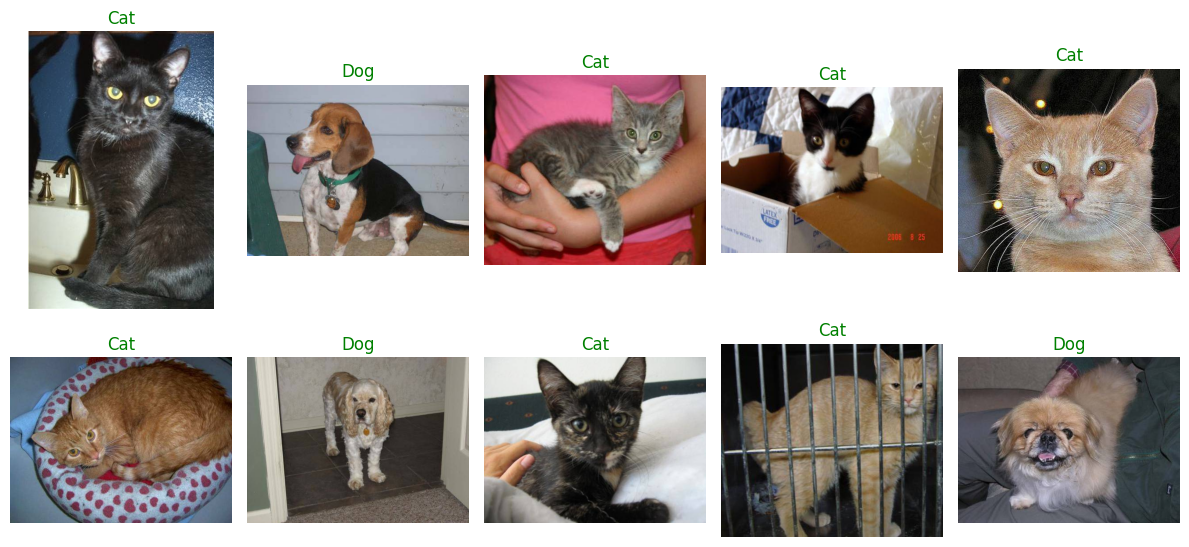

In [5]:
# 6-5 테스트 데이터셋 이미지를 출력
display_image_grid(test_images_filepaths)

In [6]:
# 6-6 이미지 데이터셋 클래스 정의
class DogvsCatDataset(Dataset):
    # 파라미터=[기본값] -> 기본값 : 아무것도 없을때 들어가는 값
    def __init__(self, file_list, transform=None, phase='train') : #데이터셋의 전처리(데이터 변형 적용) 
        self.file_list = file_list
        self.transform = transform #DogvsCatDataset 클래스를 호출할 때 transform에 대한 매개변수를 받아옴
        self.phase = phase #'train' 적용

    def __len__(self): #images_filepaths 데이터셋의 전체 길이 반환
        return len(self.file_list)

    def __getitem__(self, idx): #데이터셋에서 데이터를 가져오는 부분으로 결과는 텐서 형태
        img_path = self.file_list[idx]
        img = Image.open(img_path) # img_path 위치에서 이미지 데이터들을 가져옴
        img_transformed = self.transform(img, self.phase) #이미지에 'train' 전처리를 적용

        label = img_path.split('/')[-1].split('.')[0] #1
        if label == 'dog':
            label = 1
        elif label == 'cat':
            label = 0
        return img_transformed, label

# 1. label = img_path.split('/')[-1].split('.')[0] : 이미지 데이터에 대한 레이블 값을 가져옴
# img_path : 이미지가 위치한 전체 경로를 보여줌
# img_path.split('/')[-1] : 전체 경로에서 '/'을 제거하고 마지막 요소를 가져옴
# split('.')[0] : img_path.split('/')[-1]에서 얻은 결괴에서 '.'을 제거 후 가장 처음 요소 가져옴 

In [7]:
# 6-7 변수 값 정의
size = 224
mean = (0.485, 0.456, 0.406)
std = (0.229, 0.224, 0.225)
batch_size = 32

#        R      G      B
#mean  0.485  0.456  0.406
#std   0.229  0.224  0.225

#batch_size = 32: 한 번에 학습할 이미지 수

# 나중에 크기를 바꾸고 싶을 때 한 줄만 고치면 전체에 반영하기 위해 변수로 빼기

In [8]:
# 6-8 이미지 데이터셋 정의

#훈련 이미지에 train_tarnsforms를 적용
train_dataset = DogvsCatDataset(train_images_filepaths, transform=ImageTransform(size, mean, std), phase='train') 

#검증 이미지에 test_transforms를 적용
val_dataset = DogvsCatDataset(val_images_filepaths, transform=ImageTransform(size, mean, std), phase='val')

index = 0

print(train_dataset.__getitem__(index)[0].size()) #훈련 데이터(train_dataset.__getitem__[0][0]의 크기(size())출력
print(train_dataset.__getitem__(index)[1]) #훈련 데이터의 레이블 출력

torch.Size([3, 224, 224])
0


In [9]:
# 6-9 데이터로더 정의
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True) #1
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False) 

dataloader_dict = {'train' : train_dataloader, 'val' : val_dataloader} #훈련 데이터셋(train_dataloader)과 검증 데이터셋(val_dataset)을 합쳐서 표현

batch_iterator = iter(train_dataloader)
inputs, label = next(batch_iterator)
print(inputs.size())
print(label)

# 1. pytorch의 dataloader는 배치 관리를 담당, 한 번에 모든 데이터를 불러오면 메모리에 부담을 줄 수 있기 때문에 데이터를 그룹으로 쪼개서 조금씩 불러옴
# 첫번째 파라미터(ex. train_dataset) : 데이터를 불러오기 위한 데이터셋
# 두번째 파라미터(ex. batch_size) : 한 번에 메모리로 불러올 데이터 크기 (변수 값 가져옴 -> 32개씩)
# 세번째 파라미터(ex.shuffle) : 메모리로 데이터를 가져올 때 임의로 섞어서 가져옴 

torch.Size([32, 3, 224, 224])
tensor([0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1,
        1, 1, 0, 0, 1, 1, 1, 0])


In [10]:
# 6-10 모델의 네트워크 클래스
class LeNet(nn.Module):
    def __init__(self):
        super(LeNet, self).__init__()
        
        # 2D 합성곱층, 입력 형태는 (3, 224, 224), 출력 형태 (w - F + 2P)/S + 1 = (224-5+0)/1 + 1 = 220
        # 출력값 : (16, 220, 220)
        self.cnn1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=5, stride=1, padding=0) 
        self.relu1 = nn.ReLU() #ReLU 활성화 함수 
        # 풀링 (W1-F)/S +1, (H1-F)/S + 1 = 220-2/2 + 1= 110
        self.maxpool1 = nn.MaxPool2d(kernel_size=2) #최대 풀링이 적용, 적용 이후 출력형태가 220/2가 됨 (16, 110, 110)
        
        # 아래 계산 (110 - 5 + 2x0)/1 = 106 
        self.cnn2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=5, stride=1, padding=0) #2D 합성곱층 적용, 출력 형태(32, 106, 106)
        self.relu2 = nn.ReLU() #ReLU 활성화 함수
        # 풀링(106 - 2) / 2 + 1 = 53
        self.maxpool2 = nn.MaxPool2d(kernel_size=2) #최대 풀링이 적용, 출력 형태 (32, 53, 53)

        self.fc1 = nn.Linear(32*53*53, 512) #완전연결층1 -> nn.Linear은 한줄로만 입력받을 수 있음
        self.relu5 = nn.ReLU()
        self.fc2 = nn.Linear(512, 2) #완전연결층2
        self.output = nn.Softmax(dim=1) # 왼 -> 오


    def forward(self, x):
        out = self.cnn1(x)
        out = self.relu1(out)
        out = self.maxpool1(out)
        out = self.cnn2(out)
        out = self.relu2(out)
        out = self.maxpool2(out)
        # *nn.Linear은 한줄로만 입력받을 수 있음
        out = out.view(out.size(0), -1) #완전연결층에 데이터를 전달하기 위해 데이터 형태를 1차원으로 바꿈

        out = self.fc1(out)
        out = self.fc2(out)
        out = self.output(out)
        return out

In [11]:
# 6-11 모델 객체 생성
model = LeNet()
print(model)

LeNet(
  (cnn1): Conv2d(3, 16, kernel_size=(5, 5), stride=(1, 1))
  (relu1): ReLU()
  (maxpool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (cnn2): Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1))
  (relu2): ReLU()
  (maxpool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=89888, out_features=512, bias=True)
  (relu5): ReLU()
  (fc2): Linear(in_features=512, out_features=2, bias=True)
  (output): Softmax(dim=1)
)


In [12]:
# 6-12 torchsummary 라이브러리를 이용한 모델의 네트워크 구조 확안
from torchsummary import summary
summary(model, input_size=(3, 224, 224)) #1

# 1. summary를 통해 모델의 네트워크 관련 정보 확인
# 첫번째 파라미터 : 모델의 네트워크
# 두번째 파라미터 : 입력 값으로 (C, W, H), (3, 224, 224)를 입력 값으로 지정 

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 16, 220, 220]           1,216
              ReLU-2         [-1, 16, 220, 220]               0
         MaxPool2d-3         [-1, 16, 110, 110]               0
            Conv2d-4         [-1, 32, 106, 106]          12,832
              ReLU-5         [-1, 32, 106, 106]               0
         MaxPool2d-6           [-1, 32, 53, 53]               0
            Linear-7                  [-1, 512]      46,023,168
            Linear-8                    [-1, 2]           1,026
           Softmax-9                    [-1, 2]               0
Total params: 46,038,242
Trainable params: 46,038,242
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.57
Forward/backward pass size (MB): 19.47
Params size (MB): 175.62
Estimated Total Size (MB): 195.67
--------------------------------

In [13]:
# 6-13 학습 가능한 파라미터 수 확인
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'The model has {count_parameters(model):,} trainable parameters')
#학습 가능한 파라미터 수를 model.paramter()로 확인 

The model has 46,038,242 trainable parameters


In [14]:
# 6-14 옵티마이저와 손실 함수 정의
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9) #1
criterion = nn.CrossEntropyLoss() 

# 1. 경사 하강법으로 모멘텀 SGD를 사용 *틀린 정도(loss)를 줄이는 방향으로 가중치를 조금씩 고쳐 나가는 방법
# 모멘텀 SGD : SGD에 관성이 추가된 것으로 매번 기울기를 구하지만 가중치를 수정하기 전에 이전 수정 방향(+, -)을 참고하여 같은 방향으로 일정한 비율만 수정되게 하는 방법
# optim.SGD(model.parameters(), lr=0.001. momentum=0.9)
# 첫번째 파라미터 : 경사 하강법을 통해 궁극적으로 업데이트하고자는 파라미터는 가중치(w)와 바이어스(b)
# 두번째 파라미터(lr : learning rate) : 가중치를 변경할 때 얼마나 크게 변경할지 결정
# 세번째 파라미터(momentum) : SGD를 적절한 방향으로 가속화하여 흔들림(진동)을 줄여 주는 매개변수 

In [15]:
# 6-15 모델의 파라미터와 손실 함수를 CPU에 할당
model = model.to(device)
criterion = criterion.to(device)

In [16]:
# 6-16 모델 학습 함수 정의 *학습용도임으로 train 사용
def train_model(model, dataloader_dict, criterion, optimizer, num_epoch):
    since = time.time()
    best_acc = 0.0

    for epoch in range(num_epoch): #epoch를 10으로 설정했으므로 10회 반복
        print('Epoch {}/{}'.format(epoch+1, num_epoch))
        print('-'*20)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train() #모델 학습
            else:
                model.eval() #평가(시험) 모드로 전환

        epoch_loss = 0.0
        epoch_corrects = 0

        for inputs, labels in tqdm(dataloader_dict[phase]): #여기서 dataloader_dict는 훈련 데이터셋(train_loader) 의미
            inputs = inputs.to(device) #훈련 데이터셋을 CPU에 할당
            labels = labels.to(device) 
            optimizer.zero_grad() #역전파 단계를 실행하기 전에 기울기(gradient)를 0으로 초기화

            with torch.set_grad_enabled(phase == 'train'):
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels) #손실 함수를 이용한 오차 계산

                if phase == 'train' :
                    loss.backward() #모델의 학습 가능한 모든 파라미터에 대해 기울기 계산(역전파)
                    optimizer.step() #optimizer의 step()을 호출하면 파라미터 갱신

                epoch_loss += loss.item() * inputs.size(0) #1
                epoch_corrects += torch.sum(preds == labels.data) #정답과 예측이 일치하면 그것의 함계를 epoch_corrects에 저장

            epoch_loss = epoch_loss / len(dataloader_dict[phase].dataset) # 최종 오차 계산 (오차를 데이터셋의 길이(개수)로 나누어 계산)
            epoch_acc = epoch_corrects / len(dataloader_dict[phase].dataset) #최종 정확도 계산 (epoch_corrects를 데이터셋 길이(개수)로 나누어 계산)

            print('{} Loss: {:.4f} Acc : {:.4f}'.format(phase, epoch_loss, epoch_acc))

            if phase == 'val' and epoch_acc > best_acc: #검증 데이터셋에 대한 가장 최적의 정확도를 저장
                best_acc = epoch_acc
                best_model_wts = model.state_dict()

    time_elapsed = time.time() - since
    print('training complete in {:.0f}m {:.0f}s'.format(time_elapsed // 60, time_elapsed % 60))

    print('Best val Acc: {:4f}'.format(best_acc))
    return model

# 1. 오차와 입력을 곱하는 이유
# 손실함수 정의 : criterion = nn.CrossEntropyLoss(reduction='mean') 
# reduction의 파라미터 기본 값은 'mean' -> 정답과 예측 값의 오차를 구한 후 그 값의 평균을 반환
# -> 손실 함수 특성상 전체 오차를 배치 크기로 나눔으로써 평균을 반환하기 때문에 epoch_loss를 계산하는 동안 loss.item()과 inputs.size(0)을 곱함 
# 평균을 다시 합계로 돌리기 위해 input.size(0)을 곱합

In [17]:
# 6-17 모델 학습
import time

num_epoch = 10
model = train_model(model, dataloader_dict, criterion, optimizer, num_epoch)

Epoch 1/10
--------------------


  0%|          | 0/3 [00:00<?, ?it/s]

val Loss: 0.2401 Acc : 0.1630
val Loss: 0.2450 Acc : 0.3043
val Loss: 0.2131 Acc : 0.4674
Epoch 2/10
--------------------


  0%|          | 0/3 [00:00<?, ?it/s]

val Loss: 0.2401 Acc : 0.1630
val Loss: 0.2450 Acc : 0.3043
val Loss: 0.2131 Acc : 0.4674
Epoch 3/10
--------------------


...

val Loss: 0.2401 Acc : 0.1630
val Loss: 0.2450 Acc : 0.3043
val Loss: 0.2131 Acc : 0.4674
Epoch 9/10
--------------------


  0%|          | 0/3 [00:00<?, ?it/s]

val Loss: 0.2401 Acc : 0.1630
val Loss: 0.2450 Acc : 0.3043
val Loss: 0.2131 Acc : 0.4674
Epoch 10/10
--------------------


  0%|          | 0/3 [00:00<?, ?it/s]

val Loss: 0.2401 Acc : 0.1630
val Loss: 0.2450 Acc : 0.3043
val Loss: 0.2131 Acc : 0.4674
training complete in 0m 5s
Best val Acc: 0.467391


In [19]:
# 6-18 모델 테스트를 위한 함수 정의
import pandas as pd

id_list = []
pred_list = []
_id = 0

with torch.no_grad(): #역전파 중 텐서들에 대한 변화도를 계산할 필요가 없음을 나타내는 것, 훈련 데이터셋의 모델 학습과 가장 큰 차이
    for test_path in tqdm(test_images_filepaths): #테스트 데이터셋 이용
        img = Image.open(test_path)
        _id = test_path.split('/')[-1].split('.')[1]
        transform = ImageTransform(size, mean, std)
        
        img = transform(img, phase='val') #테스트 데이터셋 전처리 적용
        img = img.unsqueeze(0) #1
        img = img.to(device)

        model.eval() #평가(시험) 모드로 전환
        outputs = model(img)
        preds = F.softmax(outputs, dim=1)[:, 1].tolist() #2
        id_list.append(_id)
        pred_list.append(preds[0])

res = pd.DataFrame({
    'id' : id_list,
    'label' : pred_list
}) #테스트 데이터셋의 예측 결과인 id와 레이블(label)을 데이터 프레임에 저장

res.sort_values(by='id', inplace=True) #id순으로 정렬 (-> 인덱스 뒤죽박죽)
res.reset_index(drop=True, inplace=True) #인덱스 다시 번호 부여

res.to_csv('./data/LeNet', index=False) #데이터 프레임을 CSV 파일로 저장


#1. torch.unsqueeze : 텐서의 차원을 추가할 때 사용 (0)은 차원이 추가될 위치

#2. 소프트맥스(softmax) : 지정한 차원(dim)을 따라 텐서의 요소(텐서의 개별 값)가 (0,1) 범위에 있고 합계가 1이 되도록 크기를 다시 조정
# F.softmax(outputs, dim=1)[:, 1].tolist()
# (a) outputs에 softmax를 적용하면 각 행의 합이 1이 되도록 함
# (b) (a)의 값 중 모든 행(:)에서 컬럼(1번째 인덱스)을 가져옴 
# (c) 배열을 리스트 형태로 변환

  0%|          | 0/10 [00:00<?, ?it/s]

In [20]:
# 6-19 테스트 데이터셋의 예측 결과 호출
res.head(10)

#레이블 결과가 0.5보다 크면 개, 0.5보다 작으면 고양이

,id,label
0,109,0.497087
1,145,0.511157
2,15,0.504601
3,162,0.513527
4,167,0.506548
5,200,0.507324
6,210,0.505887
7,211,0.495722
8,213,0.516533
9,224,0.499807


In [25]:
# 6-20 테스트 데이터셋 이미지를 출력하기 위한 함수 정의
class_ = classes = {0:'cat', 1:'dog'} #개와 고양이에 대한 클래스 정의

def display_image_grid(images_filepaths, predicted_labels=(), cols=5):
    rows = len(images_filepaths) // cols
    figure, ax = plt.subplots(nrows=rows, ncols=cols, figsize=(12, 6))

    for i, image_filepath in enumerate(images_filepaths):
        image = cv2.imread(image_filepath)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        a = random.choice(res['id'].values) #데이터 프레임의 id라는 컬럼에서 임의로 데이터 가져옴

        label = res.loc[res['id'] == a, 'label'].values[0]

        if label > 0.5: #레이블 값이 0.5보다 크다면 개
            label = 1
        else : # 레이블 값이 0.5보다 작다면 고양이
            label = 0

        # ravel() : 여러 차원의 배열을 1차원 한 줄로 쭉 펴는 numpy 함수
        ax.ravel()[i].imshow(image)
        ax.ravel()[i].set_title(class_[label])
        ax.ravel()[i].set_axis_off()

    plt.tight_layout() #칸 사이 간격을 자동으로 정리해서 글자나 그림이 겹치지 않게해주는 함수
    plt.show()

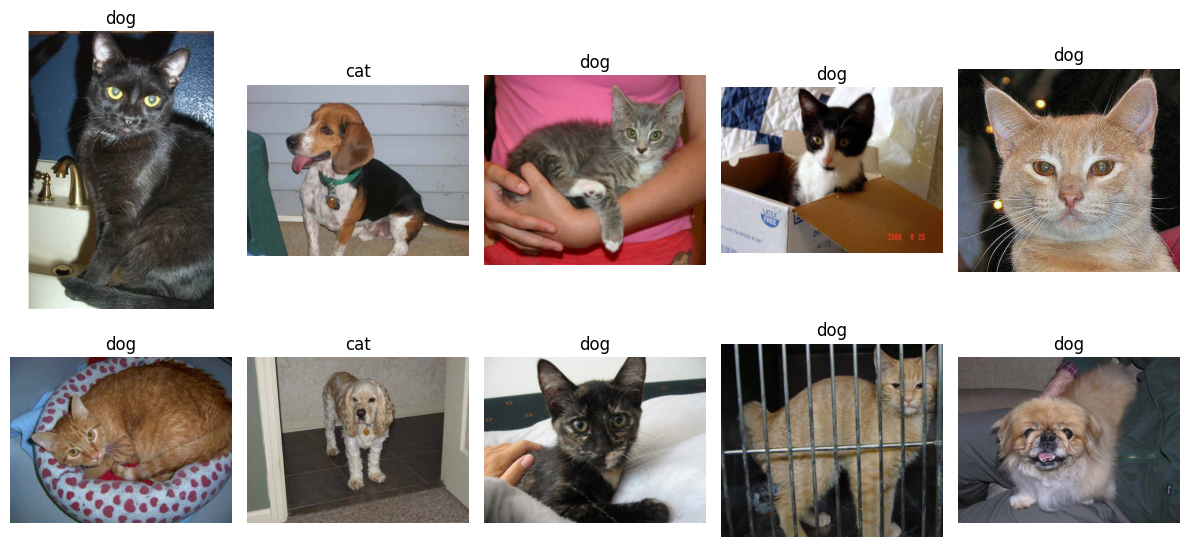

In [26]:
# 6-21 테스트 데이터셋 예측 결과 이미지 출력
display_image_grid(test_images_filepaths)